1. What Type Restaurant Do The Majority Of Customers Order From?
2. How Many Votes Has Each Type Of Restaurant Recieved From Customers?
3. What Are The Ratings That The Majority Of Restaurants Have Recieved?
4. Zomato Has Obeserved That Most Couples Order Most Of Their Food Online. wHAT iS Their Average Spending On Order?
5. Which Modes(Online Or Offline) Has Recieved The Maximum Ratings?
6. Which Type Of Restaurant Recieved More Offline Orders, So That The Zomato Can Provides Customers With Some Good Offers?


# Import Libraraies...

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns   

# Load data....

In [5]:
data = pd.read_csv('Zomato data .csv')
data.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


# Data Cleaning...


In [6]:
def handleRate(value):
    value = str(value).split('/')[0]
    return float(value) 
data['rate'] = data['rate'].apply(handleRate)
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# 1. What Type Restaurant Do The Majority Of Customers Order From?

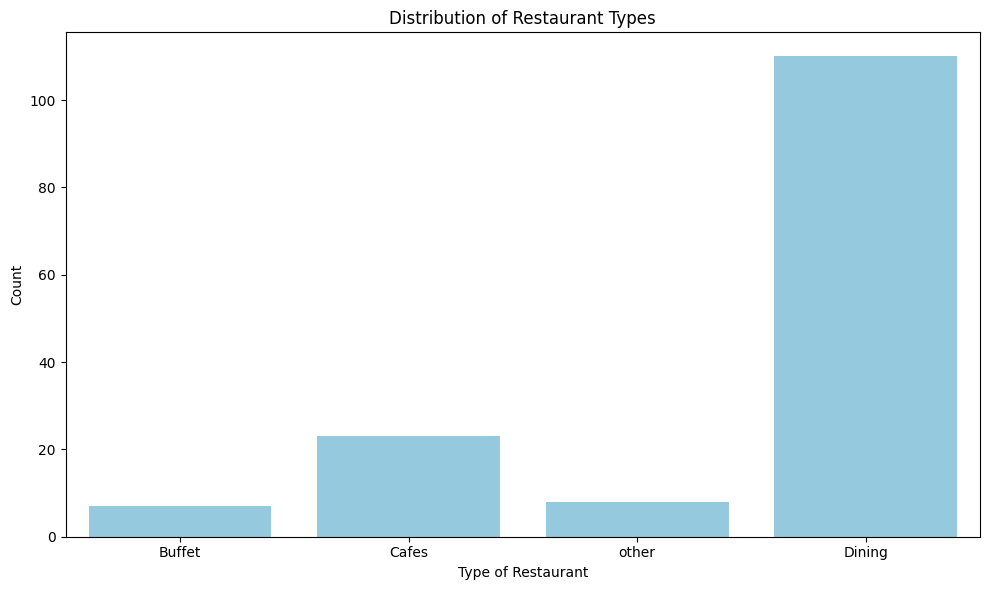

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x = 'listed_in(type)' , data = data , color = 'skyblue')
plt.xlabel('Type of Restaurant')
plt.ylabel('Count')
plt.title('Distribution of Restaurant Types')
plt.tight_layout()
plt.show()

# 2. How Many Votes Has Each Type Of Restaurant Recieved From Customers?

Text(0, 0.5, 'Votes')

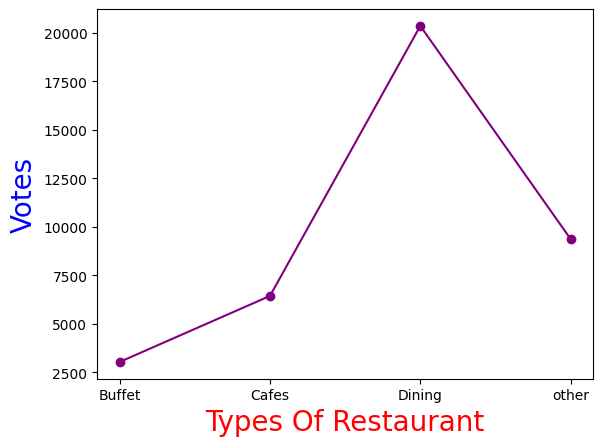

In [31]:
grouped_data = data.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result , color = 'purple' , marker = 'o')
plt.xlabel('Types Of Restaurant' , c = 'red' , size = 20)
plt.ylabel('Votes' , c = 'blue' , size = 20)

# 3. What Are The Ratings That The Majority Of Restaurants Have Recieved?

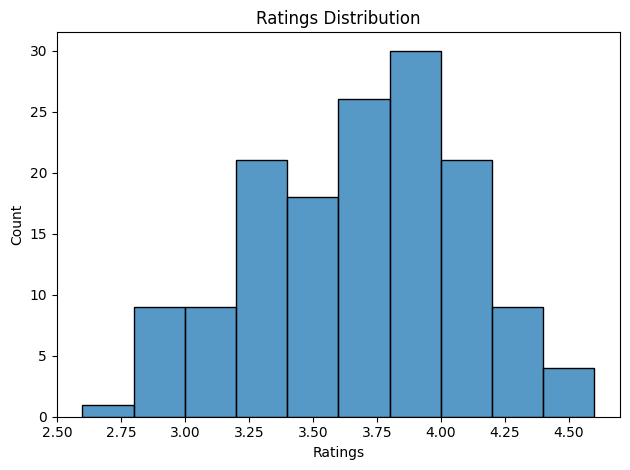

In [8]:
sns.histplot(data = data , x = 'rate' , bins = 10)
plt.title('Ratings Distribution')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Zomato Has Obeserved That Most Couples Order Most Of Their Food Online. What iS Their Average Spending On Order?

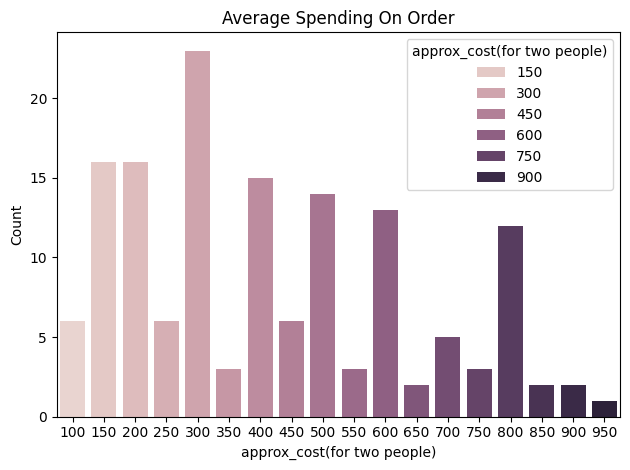

In [17]:
sns.countplot(data = data , x = 'approx_cost(for two people)' , hue='approx_cost(for two people)')
plt.title('Average Spending On Order')
plt.xlabel('approx_cost(for two people)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 5. Which Modes(Online Or Offline) Has Recieved The Maximum Ratings?

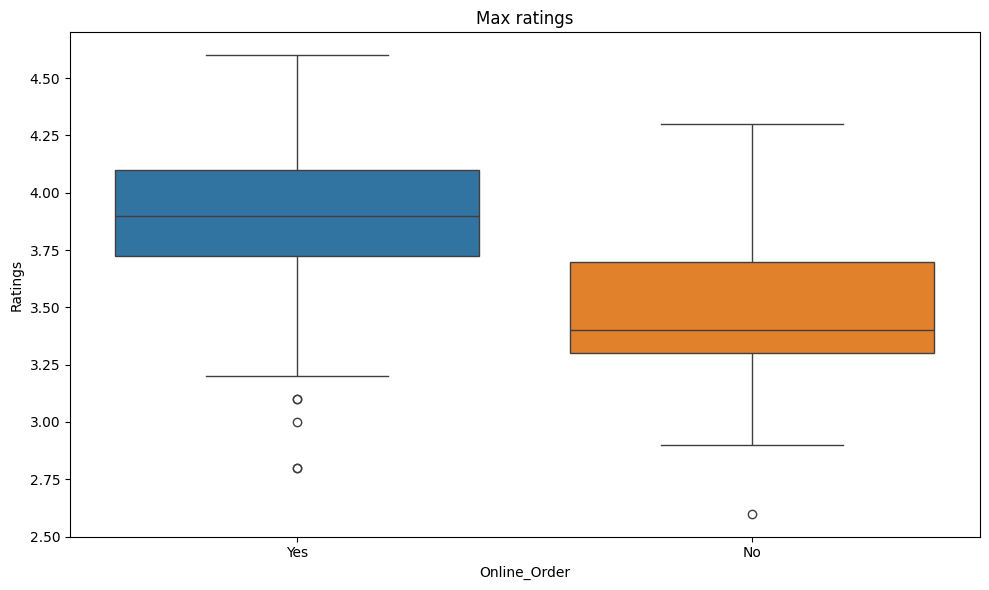

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(data = data , x = 'online_order' , y = 'rate' , hue='online_order')
plt.title('Max ratings')
plt.xlabel('Online_Order')
plt.ylabel('Ratings')
plt.tight_layout()
plt.show()

# 6. Which Type Of Restaurant Recieved More Offline Orders, So That The Zomato Can Provides Customers With Some Good Offers?

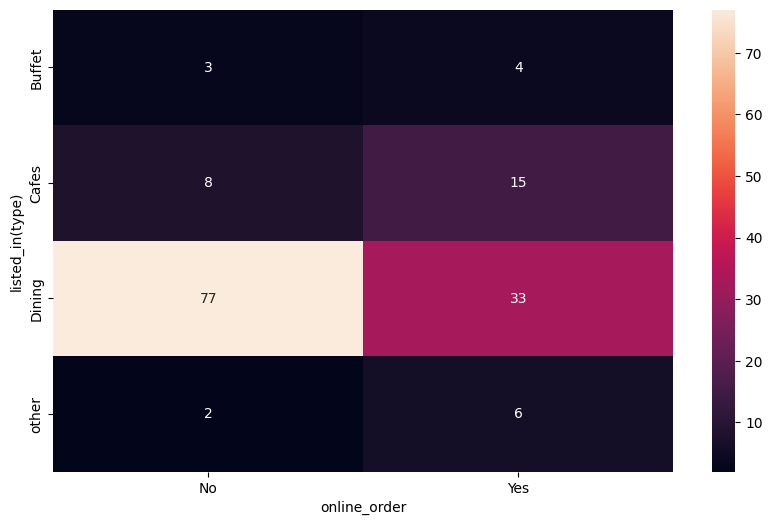

In [52]:
plt.figure(figsize=(10,6))
pivot_table = data.pivot_table(index='listed_in(type)' , columns='online_order' ,aggfunc='size' ,   fill_value=0)
sns.heatmap(pivot_table , annot=True)
plt.show()